## B104 : AI AND MACHINE LEARNING 

## Predicting Customer Subscription to Bank Term Deposits Using Machine Learning

### 1. Introduction and Problem Statement

Banks use direct marketing campaigns to promote financial products such as term deposits. However, contacting a large number of customers can require considerable time and resources, while only a proportion of customers may ultimately subscribe. Identifying customers who are more likely to subscribe could therefore help a bank target its marketing activities more effectively and improve the allocation of campaign resources.

The objective of this project is to develop a machine learning model that predicts whether a customer will subscribe to a term deposit. The problem is formulated as a supervised binary classification task, where the target variable `y` contains two possible outcomes: `yes`, indicating that the customer subscribed, and `no`, indicating that the customer did not subscribe.

The project follows an end-to-end machine learning pipeline. The dataset will first be explored to understand its characteristics, quality and class distribution. Appropriate preprocessing and feature engineering will then be performed before training and comparing classification models. The selected model will be tuned and evaluated using unseen test data. Finally, the model results will be interpreted to assess their potential value for the bank and to identify limitations and possible deployment considerations.The workflow follows the lecture's end-to-end process (Mahdavi, n.d.a).

### 2. Data Source and Dataset Description

This project uses the Bank Marketing dataset from the UCI Machine Learning Repository. The Bank Marketing dataset contains information from direct marketing campaigns conducted by a Portuguese banking institution (Moro, Rita and Cortez, 2014).

The `bank-full.csv` dataset contains 45,211 observations and 17 columns. Sixteen columns represent customer or campaign-related characteristics, while `y` is the target variable indicating whether the customer subscribed to a term deposit (`yes` or `no`). The dataset contains both numerical and categorical variables, making preprocessing necessary before applying machine learning algorithms.



### 3. Data Loading and Initial Exploration

The required Python libraries are imported and the dataset is loaded into a Pandas DataFrame. Initial inspection is performed to verify that the data has been loaded correctly and to understand its basic structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 3.1 Dataset Structure



In [4]:
df.shape

(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 4. Data Quality Assessment

Before preprocessing, the dataset is assessed for missing values, duplicate observations and potentially unknown categorical values. Although the initial inspection shows that all columns contain non-null observations, categorical variables may contain values such as `unknown` that require further investigation.

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
(df == "unknown").sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

#### 4.1 Data Quality Findings

The dataset contains no null values and no duplicate observations, indicating that no rows need to be removed for these reasons. However, several categorical variables contain the value `unknown`. This occurs in `job` (288 observations), `education` (1,857), `contact` (13,020) and `poutcome` (36,959).

These values are retained rather than removing the corresponding observations because deletion would result in substantial information loss, particularly for `poutcome`. The `unknown` values will therefore be treated as separate categorical levels during preprocessing.

### 5. Target Variable Analysis

The distribution of the target variable is examined to determine whether the classification problem is balanced. Class imbalance is important because a model may achieve high overall accuracy while performing poorly at identifying the minority class.

In [11]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [12]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

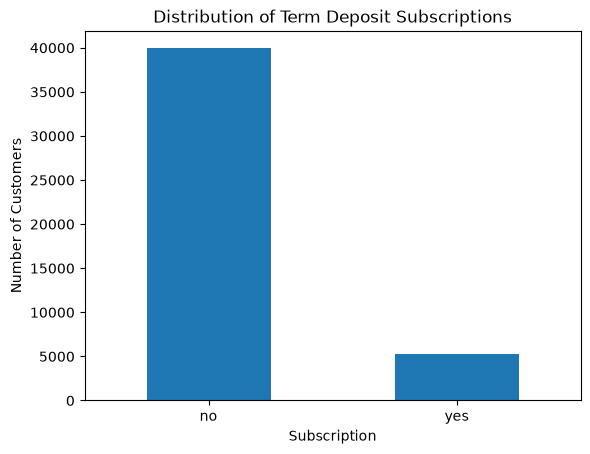

In [13]:
df["y"].value_counts().plot(kind="bar")

plt.title("Distribution of Term Deposit Subscriptions")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

#### 5.1 Target Distribution Findings

The target variable is clearly imbalanced. Approximately 88.3% of customers did not subscribe to a term deposit, while only 11.7% subscribed. Therefore, accuracy alone may not provide a sufficient measure of model performance, as a model that mainly predicts the majority class could still achieve high accuracy.

This imbalance will be considered during model evaluation. In addition to accuracy, classification metrics such as precision, recall and F1-score will be examined to better assess the model's ability to identify customers who actually subscribe.

### 6. Exploratory Data Analysis

Exploratory analysis is performed to understand the distributions of important numerical variables and investigate how selected customer and campaign characteristics relate to term deposit subscription.

#### 6.1 Customer Age

##Customer age is examined to understand its distribution and whether subscription behaviour differs across age groups.

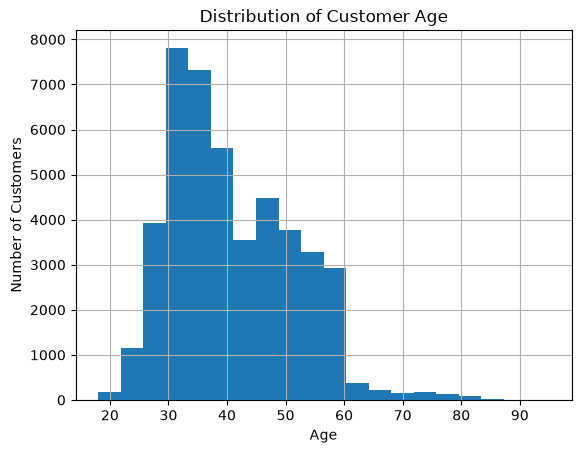

In [14]:
df["age"].hist(bins=20)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


In [15]:
df.groupby("y")["age"].mean()

y
no     40.838986
yes    41.670070
Name: age, dtype: float64

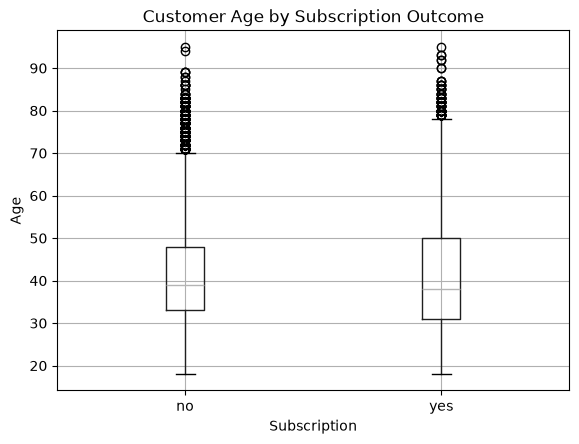

In [16]:
df.boxplot(column="age", by="y")

plt.title("Customer Age by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Age")
plt.show()

The age distribution is concentrated mainly between approximately 30 and 60 years, with relatively fewer older customers. The mean age of customers who subscribed was approximately 41.7 years, compared with 40.8 years for those who did not subscribe. The box plots also show considerable overlap between the two groups. Therefore, age alone does not appear to provide a strong separation between subscribers and non-subscribers, although it may still contribute useful information when combined with other features.

#### 6.2 Job and Subscription

Customer occupation is examined to determine whether subscription rates vary between different job categories. Proportions are used rather than raw subscription counts because the number of customers differs across occupations.

In [17]:
job_subscription = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_subscription.round(1)

y,no,yes
job,,
admin.,87.8,12.2
blue-collar,92.7,7.3
entrepreneur,91.7,8.3
housemaid,91.2,8.8
management,86.2,13.8
retired,77.2,22.8
self-employed,88.2,11.8
services,91.1,8.9
student,71.3,28.7


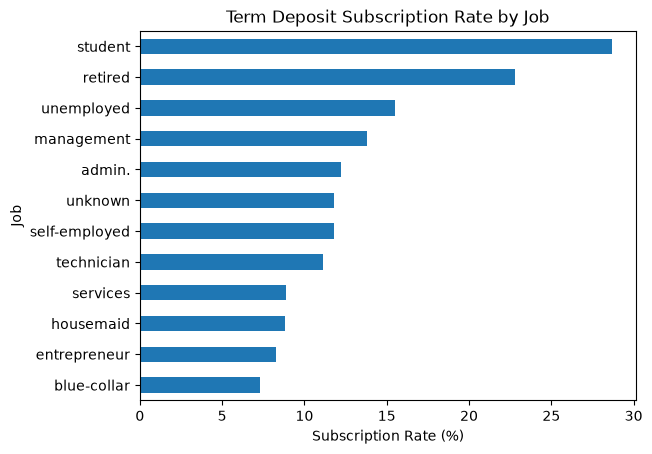

In [18]:
job_subscription.round(1)["yes"].sort_values().plot(kind="barh")

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.show()

The subscription rate varies noticeably across job categories. Students show the highest subscription rate at approximately 28.7%, followed by retired customers at approximately 22.8%. In contrast, blue-collar customers have one of the lowest subscription rates at approximately 7.3%.

This suggests that occupation may provide useful predictive information for the classification model. However, these results describe associations within the dataset and do not imply that occupation itself causes customers to subscribe.

#### 6.3 Previous Campaign Outcome

The outcome of previous marketing activity is examined to determine whether customers' previous campaign responses are associated with their current term deposit subscription.

In [19]:
poutcome_subscription = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

poutcome_subscription

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


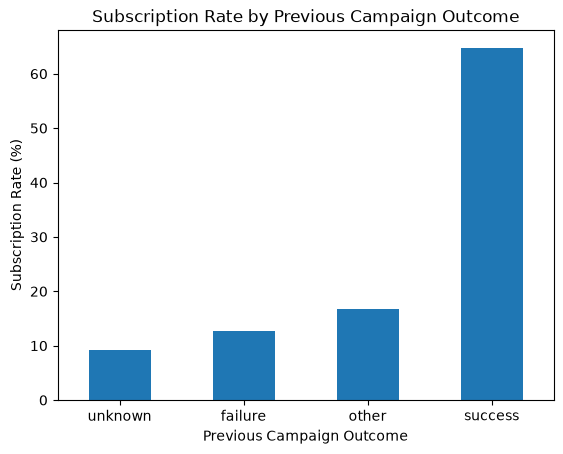

In [20]:
poutcome_subscription["yes"].sort_values().plot(kind="bar")

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.show()

Customers whose previous marketing campaign was successful show a substantially higher current subscription rate of approximately 64.7%. In comparison, customers with a previous campaign failure have a subscription rate of approximately 12.6%, while those with an unknown previous outcome have a rate of approximately 9.2%.

This indicates that previous campaign outcome may be an informative predictor of term deposit subscription. In particular, previous successful engagement appears to be strongly associated with a higher probability of subscription in the current campaign.

#### 6.4 Housing Loan and Subscription

The relationship between housing loan status and term deposit subscription is examined to determine whether customers with an existing housing loan show different subscription behaviour.

In [21]:
housing_subscription = pd.crosstab(
    df["housing"],
    df["y"],
    normalize="index"
) * 100

housing_subscription.round(1)

y,no,yes
housing,,
no,83.3,16.7
yes,92.3,7.7


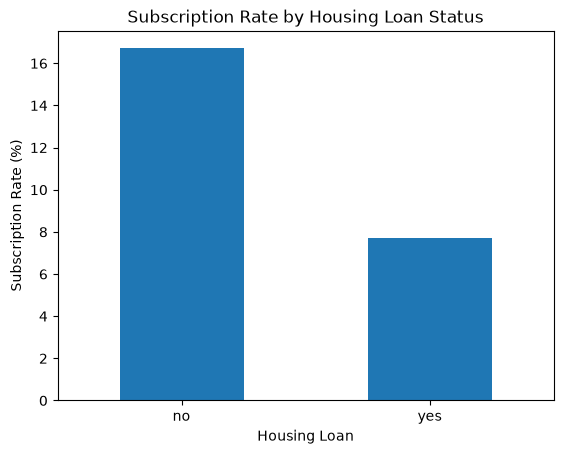

In [22]:
housing_subscription["yes"].plot(kind="bar")

plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.show()

Customers without a housing loan have a subscription rate of approximately 16.7%, compared with approximately 7.7% for customers with a housing loan. This indicates an association between housing loan status and term deposit subscription, with customers without an existing housing loan showing a higher tendency to subscribe. Housing status may therefore provide useful information for the classification models.

#### 6.5 Contact Duration and Subscription

Contact duration is examined because it may contain useful information about customer engagement during a marketing call. The distribution of call duration is compared between customers who subscribed and those who did not.

In [23]:
df.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


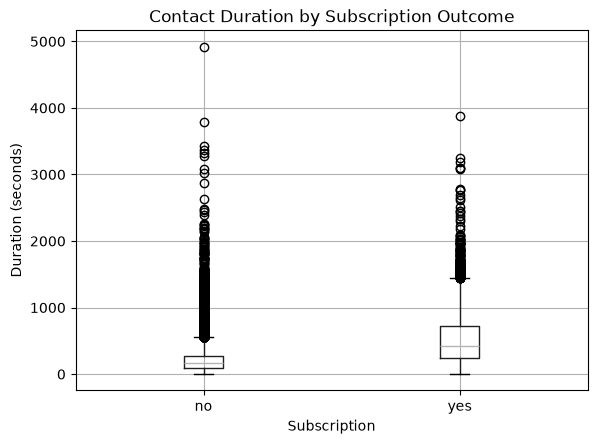

In [24]:
df.boxplot(column="duration", by="y")

plt.title("Contact Duration by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Duration (seconds)")
plt.show()

Customers who subscribed had considerably longer contact durations. The mean duration was approximately 537 seconds for subscribers compared with 221 seconds for non-subscribers, while the median durations were 426 and 164 seconds respectively. This indicates a strong association between contact duration and subscription.

However, contact duration is only known once a marketing call has taken place. Since the business objective is to identify promising customers for targeting before contact, this variable would not be available when the prediction is required. Therefore, `duration` will be excluded from the predictive features to ensure that the final model better reflects the intended business use case.

#### 6.6 Exploratory Analysis Summary

The exploratory analysis identified several potentially informative relationships. Customer age showed considerable overlap between subscribers and non-subscribers, whereas occupation, housing loan status and previous campaign outcome showed clearer differences in subscription rates. In particular, customers with a previously successful campaign outcome demonstrated a substantially higher subscription rate.

The target variable is imbalanced, with only approximately 11.7% of customers subscribing. This will be considered when evaluating the classification models. Although contact duration showed a strong relationship with subscription, it will be excluded because it would not be known before a customer is contacted.

### 7. Data Preprocessing

The dataset must be transformed into a numerical format suitable for machine learning. The target variable is separated from the predictor variables, `duration` is excluded based on the previous analysis, and categorical predictors are encoded numerically. The data will then be divided into training and test sets so that final model performance can be evaluated on unseen observations.

In [25]:
x = df.drop(columns=["y", "duration"])
y = df["y"]

In [26]:
x.shape, y.shape

((45211, 15), (45211,))

In [27]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='str')

#### 7.1 Target Encoding

The binary target variable is converted into numerical form, where `no` is represented by 0 and `yes` by 1. This allows the target to be used directly by the classification algorithms.

In [28]:
y = y.map({"no": 0, "yes": 1})

In [29]:
y.value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [30]:
categorical_cols = x.select_dtypes(include="str").columns
numerical_cols = x.select_dtypes(include=np.number).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')

Numerical columns:
Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='str')


### 7.2 Training and Test Split

The dataset is divided into training and test sets. The training data is used for model development, while the test data is retained for evaluating performance on unseen observations. An 80/20 split is used, and stratification preserves the original proportion of subscribers and non-subscribers in both sets.

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training features:", x_train.shape)
print("Test features:", x_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (36168, 15)
Test features: (9043, 15)
Training target: (36168,)
Test target: (9043,)


### 7.3 Feature Transformation

The predictor variables contain both numerical and categorical features. Categorical variables are transformed using one-hot encoding so that they can be processed by the machine learning algorithms without introducing an artificial ordering between categories. Numerical variables are standardised so that features measured on different scales are comparable. The transformations are fitted using the training data and subsequently applied to the test data.

In [35]:
## importing the preprocessing tools
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [36]:
##creating the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [37]:
OneHotEncoder(handle_unknown="ignore")

##converts categories to binary columns 

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [38]:
## fitting the training data only

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [39]:
print("Training data:", x_train_processed.shape)
print("Test data:", x_test_processed.shape)

Training data: (36168, 50)
Test data: (9043, 50)


In [40]:
##checking the class split

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Test target distribution:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


### 7.4 Training and Validation Split

The training data is further divided into training and validation subsets. The validation subset is used for model comparison and hyperparameter selection, while the test set is reserved for the final model assessment.

In [41]:
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", x_train_sub.shape)
print("Validation subset:", x_val.shape)
print("Test set:", x_test_processed.shape)

Training subset: (28934, 50)
Validation subset: (7234, 50)
Test set: (9043, 50)


## 8. Model Development

Classification models are now trained using the preprocessed training data. Logistic Regression was used as one of the classification models in this study because it is suitable for binary classification and provides a relatively interpretable approach for predicting whether a customer will subscribe to a term deposit. (Mahdavi, n.d.a)

### 8.1 Logistic Regression


In [42]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(x_train_sub, y_train_sub)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [43]:


y_pred_log = log_model.predict(x_val)

### 8.2 Logistic Regression Evaluation

The predictions are evaluated using multiple classification metrics. Because the target variable is imbalanced, accuracy is considered alongside precision, recall and F1-score to provide a more complete assessment of model performance.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [45]:
print("Accuracy:", accuracy_score(y_val, y_pred_log))
print("Precision:", precision_score(y_val, y_pred_log))
print("Recall:", recall_score(y_val, y_pred_log))
print("F1-score:", f1_score(y_val, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_log))

Accuracy: 0.8941111418302461
Precision: 0.6801801801801802
Recall: 0.17848699763593381
F1-score: 0.28277153558052437

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      6388
           1       0.68      0.18      0.28       846

    accuracy                           0.89      7234
   macro avg       0.79      0.58      0.61      7234
weighted avg       0.88      0.89      0.87      7234


Confusion Matrix:
[[6317   71]
 [ 695  151]]


In [46]:
confusion_matrix(y_val, y_pred_log)

array([[6317,   71],
       [ 695,  151]])

### 8.3 Logistic Regression Findings

Logistic Regression achieved an overall accuracy of approximately 89.41%. However, the class-specific results reveal weaker performance for customers who actually subscribed. For the positive class, precision was approximately 68.02%, while recall was only 17.85% and the F1-score was approximately 28.28%.

The confusion matrix shows that the model correctly identified 151 subscribers but failed to identify 695 actual subscribers. Therefore, although the model achieves high overall accuracy and relatively high precision when predicting subscription, its low recall indicates that it predicts the majority non-subscriber class too frequently. This demonstrates why accuracy alone is insufficient for evaluating the current imbalanced classification problem.

### 8.4 Second model : K-Nearest Neighbours

K-Nearest Neighbours (KNN) is trained as a second classification approach. KNN classifies observations based on their neighbouring data points, with the value of k acting as an important hyperparameter (Mahdavi, n.d.b). Since the numerical predictors have already been standardised, differences in their original measurement scales will not disproportionately influence the distance calculations.

In [47]:
from sklearn.neighbors import KNeighborsClassifier

In [48]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(x_train_sub, y_train_sub)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [49]:

y_pred_knn = knn_model.predict(x_val)

In [50]:
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("Precision:", precision_score(y_val, y_pred_knn))
print("Recall:", recall_score(y_val, y_pred_knn))
print("F1-score:", f1_score(y_val, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_knn))

Accuracy: 0.8860934476085154
Precision: 0.5325443786982249
Recall: 0.2127659574468085
F1-score: 0.30405405405405406

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6388
           1       0.53      0.21      0.30       846

    accuracy                           0.89      7234
   macro avg       0.72      0.59      0.62      7234
weighted avg       0.86      0.89      0.86      7234


Confusion Matrix:
[[6230  158]
 [ 666  180]]


### 8.5 KNN Findings

The KNN model achieved an accuracy of approximately 88.61%, with precision of 53.25%, recall of 21.28% and an F1-score of 30.41% for the subscriber class. The confusion matrix shows that KNN correctly identified 180 of the 846 actual subscribers while failing to identify 666.

Compared with Logistic Regression, KNN achieved slightly higher recall and F1-score, meaning that it identified more actual subscribers. However, its precision and overall accuracy were lower. Both models therefore show difficulty identifying the minority subscriber class, which is consistent with the class imbalance observed during exploratory analysis.

### 8.6 Initial Model Comparison

The two classification models are compared using the same validation data and evaluation metrics. Particular attention is given to recall and F1-score because identifying subscribers is important for the business problem and the target variable is imbalanced.

In [51]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (k=5)"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn)
    ]
})

model_comparison.round(3)



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.894,0.680,0.178,0.283
1,KNN (k=5),0.886,0.533,0.213,0.304


## 9. Hyperparameter Tuning

The initial KNN model used five neighbours. However, the number of neighbours (`k`) is a hyperparameter that can influence model performance. Several values of `k` are therefore evaluated to examine whether the model can achieve better classification performance. F1-score is considered alongside accuracy, precision and recall because the target variable is imbalanced.

In [52]:
k_values = [3, 5, 7, 9, 11, 15, 21]

knn_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_sub, y_train_sub)

    predictions = model.predict(x_val)

    knn_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1-score": f1_score(y_val, predictions)
    })

knn_tuning_results = pd.DataFrame(knn_results)

knn_tuning_results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}"
}).set_caption("KNN Hyperparameter Tuning Results")

,k,Accuracy,Precision,Recall,F1-score
0,3,0.878,0.461,0.246,0.321
1,5,0.886,0.533,0.213,0.304
2,7,0.890,0.580,0.209,0.308
3,9,0.889,0.583,0.182,0.277
4,11,0.889,0.590,0.175,0.270
5,15,0.891,0.633,0.165,0.262
6,21,0.892,0.667,0.161,0.259


### 9.1 KNN Tuning Results/Interpretation

Among the tested values of k, k = 3 achieved the highest F1-score of approximately 0.321 and the highest recall of approximately 0.246 on the validation set. Its accuracy was approximately 87.8%, with a precision of 46.1%. As k increased, precision generally improved, but recall decreased, meaning that fewer actual subscribers were correctly identified. Since the target variable is imbalanced and identifying subscribers is important for the business problem, the F1-score was used to balance precision and recall when selecting the model. Therefore, k = 3 was selected as the tuned KNN configuration for final model assessment.

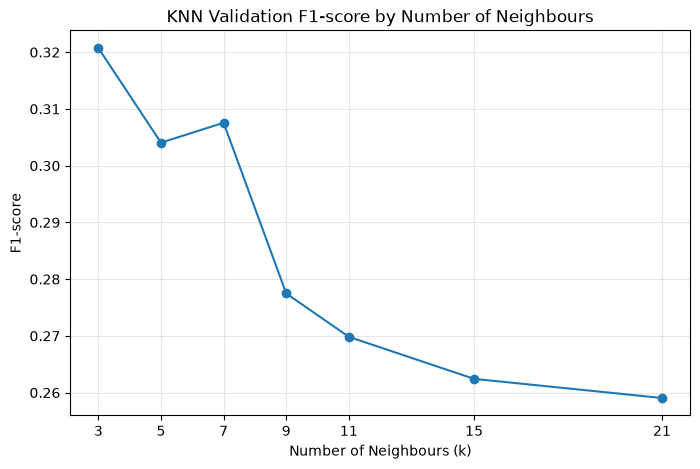

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_tuning_results["k"],
    knn_tuning_results["F1-score"],
    marker="o"
)

plt.title("KNN Validation F1-score by Number of Neighbours")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("F1-score")
plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

## 10. Final Model Assessment



### 10.1 Final Model Training

In [54]:
final_knn = KNeighborsClassifier(n_neighbors=3)

final_knn.fit(x_train_processed, y_train)

y_pred_final = final_knn.predict(x_test_processed)

### 10.2 Final Test Performance

In [55]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_final):.3f}")

report = classification_report(
    y_test,
    y_pred_final,
    target_names=["No Subscription", "Subscription"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.round(3)

Accuracy:  0.882
Precision: 0.490
Recall:    0.242
F1-score:  0.324


,precision,recall,f1-score,support
No Subscription,0.906,0.967,0.935,7985.000
Subscription,0.490,0.242,0.324,1058.000
accuracy,0.882,0.882,0.882,0.882
macro avg,0.698,0.604,0.630,9043.000
weighted avg,0.857,0.882,0.864,9043.000


The tuned KNN model with k=3 achieved an accuracy of approximately 88.2% on the unseen test set. However, because the dataset is highly imbalanced, accuracy alone does not provide a complete indication of model performance. For the subscriber class, the model achieved a precision of approximately 49.0%, recall of 24.2%, and an F1-score of 32.4%. The confusion matrix shows that the model correctly identified 256 subscribers but failed to identify 802 actual subscribers. Therefore, although the model performs well when identifying non-subscribers, its ability to detect potential subscribers remains limited. This is an important limitation for the business objective because many customers who may subscribe would not be identified by the model.


### 10.3 Confusion Matrix

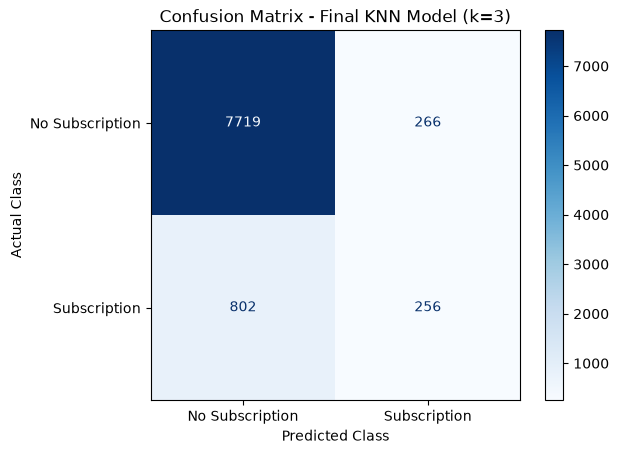

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["No Subscription", "Subscription"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Final KNN Model (k=3)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Final Model Performance Visualisation

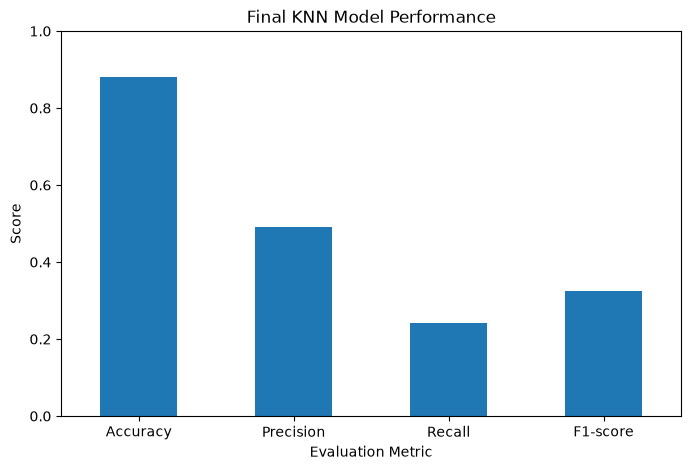

In [57]:
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1-score": f1_score(y_test, y_pred_final)
})

final_metrics.plot(kind="bar", figsize=(8, 5))

plt.title("Final KNN Model Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 11. Final Discussions and Findings
The final KNN model with k=3 achieved 88.2% accuracy, 49.0% precision, 24.2% recall and 32.4% F1-score on the unseen test data. Although the accuracy is high, the low recall shows that the model is much better at identifying non-subscribers than subscribers. Out of 1,058 actual subscribers, only 256 were correctly identified while 802 were missed. Exploratory analysis also showed notable associations with previous campaign outcome, occupation and housing-loan status, although these should not be interpreted as causal relationships.

From a business perspective, the model could assist the bank in prioritising customers for marketing campaigns, but it should not be used as an automatic targeting system because many potential subscribers would be missed. The model should first be validated using more recent campaign data, with particular attention to recall, precision and F1-score. The class imbalance and limited interpretability of KNN should also be considered before practical deployment.

## 12. Conclusion

This project examined whether customer and campaign characteristics could predict term-deposit subscription. KNN with k=3 was selected based on validation performance and achieved an F1-score of 32.4% on unseen test data. The results show some potential for supporting customer prioritisation, but the low subscriber recall remains an important limitation. Further validation and improvement would therefore be required before the model could be used in a real marketing campaign.

## 13. References

Mahdavi, M. (n.d.a) *Introduction to Machine Learning* [Lecture slides]. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.a) *Logistic Regression* [Lecture slides]. B104 Artificial Intelligence & Machine Learning. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.b) *K-Nearest Neighbours* [Lecture slides]. B104 Artificial Intelligence & Machine Learning. Gisma University of Applied Sciences, B104.

Mahdavi, M. (n.d.c) *Classification Evaluation* [Lecture slides]. B104 Artificial Intelligence & Machine Learning. Gisma University of Applied Sciences, B104.

Moro, S., Rita, P. and Cortez, P. (2014) *Bank Marketing* [Dataset]. UCI Machine Learning Repository. Available at:  https://archive.ics.uci.edu/dataset/222/bank+marketing (Accessed : 8 September 2026).